In [24]:
# get relevant info about .nc file

def get_nc_info(PATH: str, temp_var: str | None = None):
    import xarray as xr
    import numpy as np
    
    ds = xr.open_dataset(PATH, decode_times=False)
    
    print(f"=== FILE: {PATH} ===\n")
    
    # 1. Identify the temperature variable
    if temp_var is not None:
        if temp_var in ds.data_vars:
            temp_vars = [temp_var]
            print(f"Using user-specified temperature variable: {temp_var}")
        else:
            print(f"⚠  '{temp_var}' not found in file. Available data variables:")
            for v in ds.data_vars:
                print(f"    - {v}")
            ds.close()
            return  # bail out — nothing sensible to inspect for a missing var
    else:
        TEMP_CANDIDATES = ["tas", "tair", "t2m", "TREFHT", "temp", "air",
                           "TS", "ts", "T2", "temperature"]
        temp_vars = [v for v in ds.data_vars if v in TEMP_CANDIDATES]
        print(f"Likely temperature variable(s): {temp_vars}")
    
    print(f"All data variables: {list(ds.data_vars)}\n")
    
    # 2. For each candidate: units, shape, dims
    for v in temp_vars or list(ds.data_vars):
        da = ds[v]
        print(f"--- {v} ---")
        print(f"  long_name : {da.attrs.get('long_name', 'n/a')}")
        print(f"  units     : {da.attrs.get('units', 'n/a')}   # K vs degC matters!")
        print(f"  dims      : {da.dims}")
        print(f"  shape     : {da.shape}")
        print(f"  dtype     : {da.dtype}")
        print(f"  _FillValue: {da.attrs.get('_FillValue', da.encoding.get('_FillValue', 'n/a'))}")
        print()
    
    # 3. Coordinates
    print("--- Coordinates ---")
    for name, c in ds.coords.items():
        vals = c.values
        if np.issubdtype(vals.dtype, np.number):
            print(f"  {name:12s} size={c.size:6d}  min={vals.min()}  max={vals.max()}  "
                  f"units={c.attrs.get('units', 'n/a')}")
        else:
            print(f"  {name:12s} size={c.size:6d}  units={c.attrs.get('units', 'n/a')}")
    
    # Longitude convention
    lon_name = next((n for n in ["lon", "longitude", "nav_lon", "x"] if n in ds.coords), None)
    if lon_name:
        lo, hi = float(ds[lon_name].min()), float(ds[lon_name].max())
        conv = "0..360" if hi > 180 else "-180..180"
        print(f"\n  Longitude convention: {conv}")
    
    # Grid type + resolution
    lat_name = next((n for n in ["lat", "latitude", "nav_lat", "y"] if n in ds.coords), None)
    if lat_name and lon_name:
        print(f"  Grid type: {'regular 1D' if ds[lat_name].ndim == 1 else '2D / curvilinear'}")
        if ds[lat_name].ndim == 1 and ds[lat_name].size > 1:
            dlat = float(np.abs(np.diff(ds[lat_name].values)).mean())
            dlon = float(np.abs(np.diff(ds[lon_name].values)).mean())
            print(f"  Resolution: {dlat:.3f}° lat × {dlon:.3f}° lon")
    
    # 4. TIME — handle paleo "years since present" manually
    if "time" in ds.coords:
        t = ds["time"]
        t_units = t.attrs.get("units", "n/a")
        print(f"\n--- Time (raw, not auto-decoded) ---")
        print(f"  units    : {t_units}")
        print(f"  dtype    : {t.dtype}")
        print(f"  n_steps  : {t.size}")
        print(f"  range    : {t.values.min()}  →  {t.values.max()}")
        print(f"  step     : {np.diff(t.values)[:3]} ... (first 3 differences)")
        # Interpret: "years since present" → present = 1950 by BP convention
        if "years since present" in t_units.lower() or "year" in t_units.lower():
            print(f"  → interpreted as years BP (Before Present, present=1950)")
            print(f"  → time span: {abs(t.values.min())} to {abs(t.values.max())} years BP")
    
    # 5. Global attrs
    print("\n--- Global attrs ---")
    for k, v in ds.attrs.items():
        print(f"  {k}: {v}")
    
    ds.close()

In [28]:
from pathlib import Path

beyer2020_air = str(Path.cwd() / "data" / "Beyer2020" / "data" / "LateQuaternary_Environment.nc")
palmod2_air = str(Path.cwd() / "data" / "PalMod2" / "output" / "PMMXMCRTDGr111Amtasgn30201_1-250.nc")
palmod2_soil = str(Path.cwd() / "data" / "PalMod2" / "output" / "PMMXMCRTDGr111Lmtslgn30201_1-250.nc")
trace_air = str(Path.cwd() / "data" / "TraCE-21k" / "data" / "trace.01-36.22000BP.clm2.TSA.22000BP_decavg_400BCE.nc")
trace_soil = str(Path.cwd() / "data" / "TraCE-21k" / "data" / "trace.01-36.22000BP.clm2.TSOI.22000BP_decavg_400BCE.nc")
chelsa_air = str(Path.cwd() / "data" / "CHELSA-TraCE21k-centennial" / "output" / "tasmean.nc")


In [27]:
get_nc_info(chelsa_air, "tasmean")

=== FILE: /home/lghomeoffice/git/paleoclimate_model_comparison/data/CHELSA-TraCE21k-centennial/output/tasmean.nc ===

Using user-specified temperature variable: tasmean
All data variables: ['tasmean']

--- tasmean ---
  long_name : n/a
  units     : n/a   # K vs degC matters!
  dims      : ('time', 'lat', 'lon')
  shape     : (221, 46, 96)
  dtype     : float32
  _FillValue: nan

--- Coordinates ---
  time         size=   221  min=0.0  max=8035335.0  units=days since -20010-07-01 00:00:00.000000
  lon          size=    96  min=-178.12513889635002  max=178.12485967865  units=n/a
  lat          size=    46  min=-86.62513890235  max=82.12486042265002  units=n/a

  Longitude convention: -180..180
  Grid type: regular 1D
  Resolution: 3.750° lat × 3.750° lon

--- Time (raw, not auto-decoded) ---
  units    : days since -20010-07-01 00:00:00.000000
  dtype    : float64
  n_steps  : 221
  range    : 0.0  →  8035335.0
  step     : [36525. 36524. 36524.] ... (first 3 differences)

--- Global at

Target  : 52.5244°N, 13.4105°E  (Brandenburg Gate, Berlin)
Cell hit: 52.750°N, 13.250°E


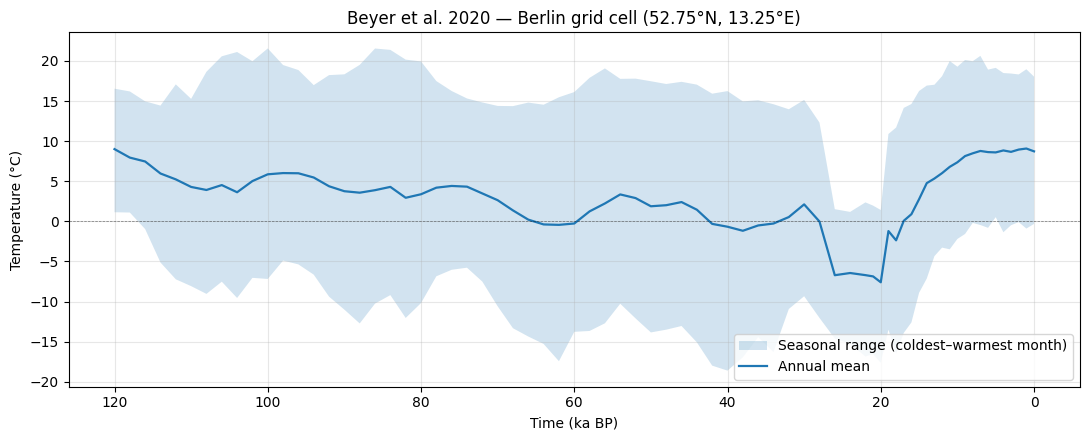

In [2]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt

PATH = "/home/lghomeoffice/git/paleoclimate_model_comparison/data/Beyer2020/data/LateQuaternary_Environment.nc"

# DMS → decimal degrees
# 52°31'27.73"N → 52 + 31/60 + 27.73/3600
# 13°24'37.91"E → 13 + 24/60 + 37.91/3600
lat_pt = 52 + 31/60 + 27.73/3600
lon_pt = 13 + 24/60 + 37.91/3600
print(f"Target  : {lat_pt:.4f}°N, {lon_pt:.4f}°E  (Brandenburg Gate, Berlin)")

ds = xr.open_dataset(PATH, decode_times=False)

# .sel(method="nearest") snaps to the closest grid cell.
# Grid is 0.5° → worst-case offset ≈ 0.25° ≈ 28 km at this latitude. Fine for paleoclimate.
ts = ds["temperature"].sel(latitude=lat_pt, longitude=lon_pt, method="nearest")
print(f"Cell hit: {float(ts.latitude):.3f}°N, {float(ts.longitude):.3f}°E")

# ts has dims (time, month). The 12 month values are climatological monthly means
# for each 2000-year slice → mean over `month` gives annual mean temperature.
annual = ts.mean(dim="month")          # shape (72,) — one value per time slice
month_min = ts.min(dim="month")        # coldest month (≈ January here)
month_max = ts.max(dim="month")        # warmest month (≈ July here)

# Time is "years since present" with present = 1950 BP convention.
# Negative = past. Flip sign and divide by 1000 → ka BP (thousand years before present).
time_ka = -ts["time"].values / 1000    # 0 → 120

# --- plot ---
fig, ax = plt.subplots(figsize=(11, 4.5))
ax.fill_between(time_ka, month_min, month_max,
                alpha=0.2, label="Seasonal range (coldest–warmest month)")
ax.plot(time_ka, annual.values, lw=1.6, label="Annual mean")
ax.invert_xaxis()                       # paleoclimate convention: past on the left
ax.set_xlabel("Time (ka BP)")
ax.set_ylabel("Temperature (°C)")
ax.set_title(f"Beyer et al. 2020 — Berlin grid cell "
             f"({float(ts.latitude):.2f}°N, {float(ts.longitude):.2f}°E)")
ax.axhline(0, color="k", lw=0.5, ls="--", alpha=0.5)
ax.grid(alpha=0.3)
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

ds.close()